In [241]:
import pandas as pd
import numpy as np
import hist
import matplotlib as mpl
import mplhep
#import mplhep.error_estimation will come back to this later
mpl.style.use(mplhep.style.ROOT)
import matplotlib.pyplot as plt
import scipy
from scipy import optimize
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import yaml
from statistics import mean 

In [242]:
pedestal = pd.read_csv('default_pedestal_10k.csv')

In [243]:
# define a unique ID for each channel to make histograms a bit easier to make
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [244]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

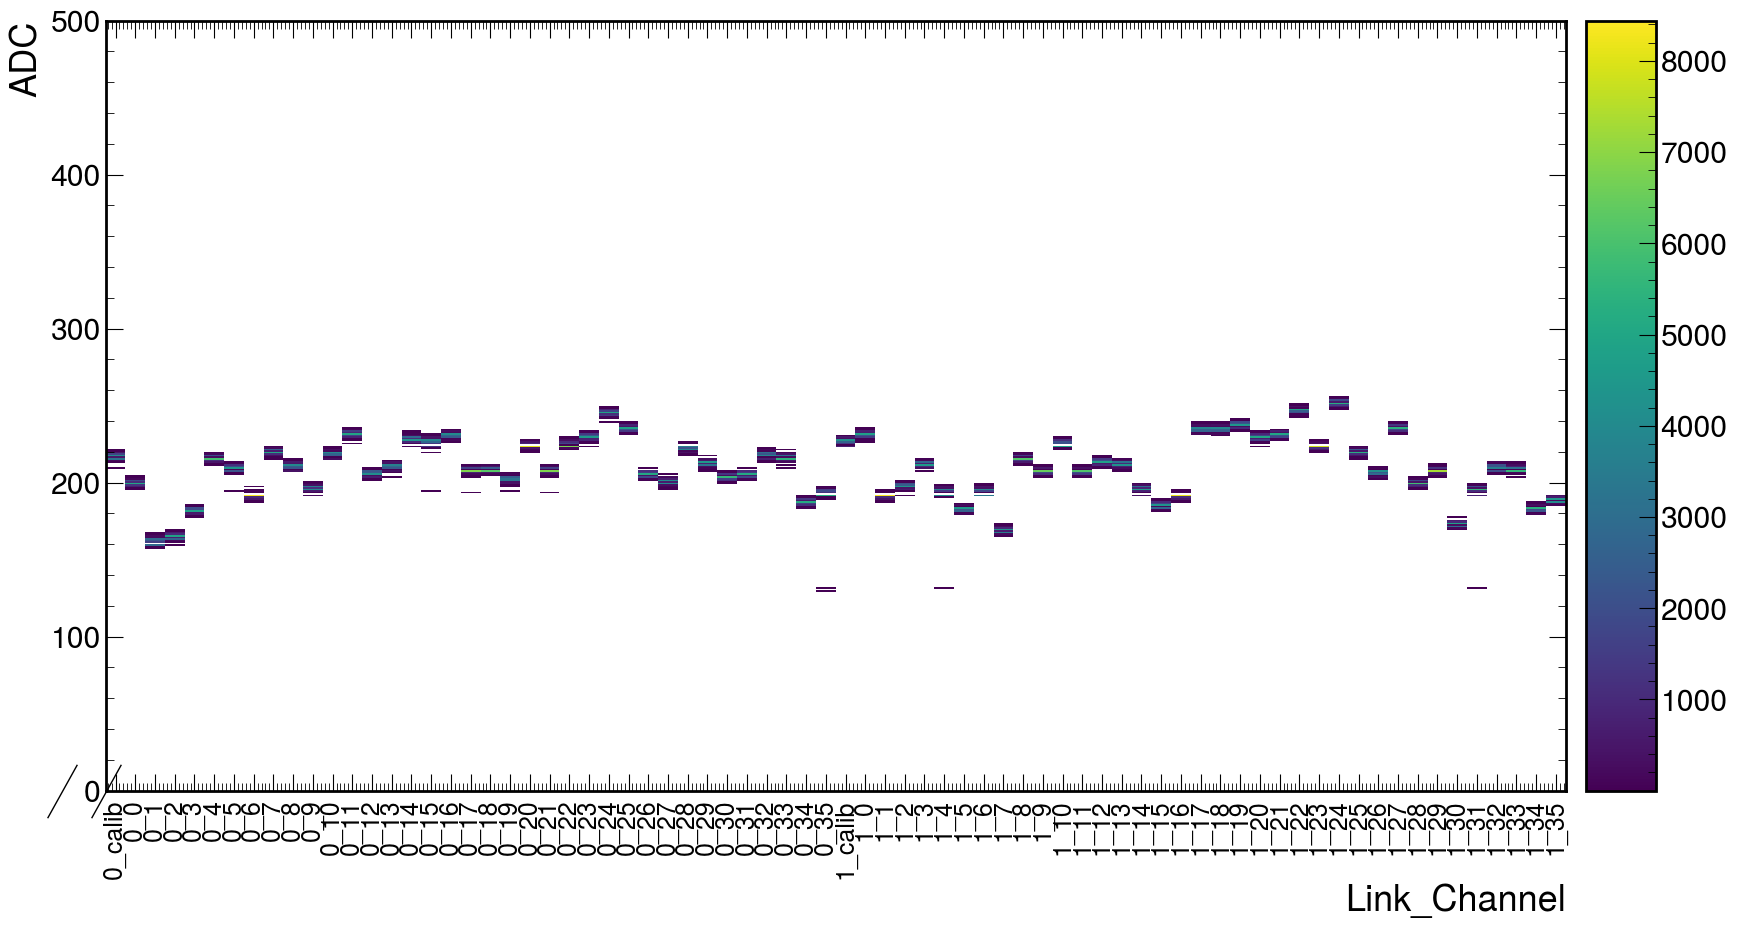

In [245]:
#general ADC Plot #128.256
fill_and_plot_all_channels('adc','ADC',0,500)

In [246]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]


In [247]:

link_0.describe() #looking at the new arrays generated

,i_link,bx,event,orbit,adc_tm1,adc,tot,toa
count,370000.0,370000.0,370000.000000,370000.000000,370000.000000,370000.000000,370000.0,370000.0
mean,0.0,14.0,31.496700,3.508800,209.544727,209.532405,-1.0,0.0
std,0.0,0.0,18.470737,2.290357,17.688148,17.690399,0.0,0.0
min,0.0,14.0,0.000000,0.000000,131.000000,129.000000,-1.0,0.0
25%,0.0,14.0,16.000000,2.000000,201.000000,201.000000,-1.0,0.0
50%,0.0,14.0,31.000000,4.000000,210.000000,210.000000,-1.0,0.0
75%,0.0,14.0,47.250000,6.000000,223.000000,223.000000,-1.0,0.0
max,0.0,14.0,63.000000,7.000000,249.000000,249.000000,-1.0,0.0


In [248]:
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']

Text(0.5, 1.0, 'Link 0')

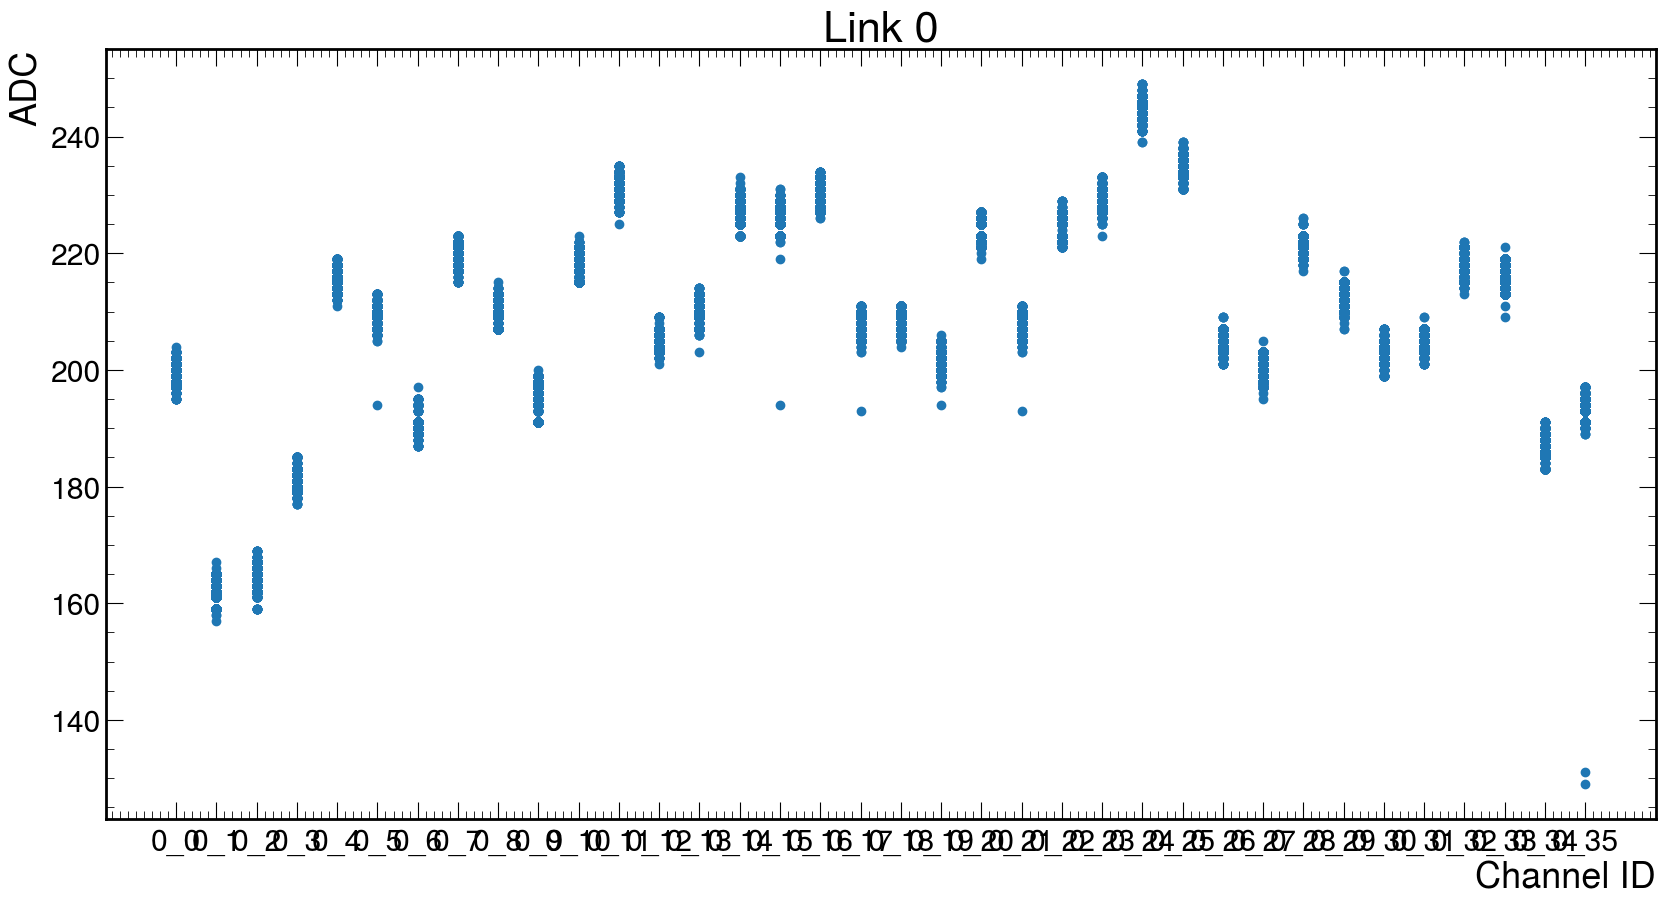

In [249]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [250]:
print ("Link 0 median ADC is " + str(link_0_norm['adc'].median()) + " without calibration channels")
print ("Link 0 mean ADC is " + str(link_0_norm['adc'].mean()) + " without calibration channels")



Link 0 median ADC is 209.0 without calibration channels
Link 0 mean ADC is 209.33851944444444 without calibration channels


Text(0.5, 1.0, 'Link 0')

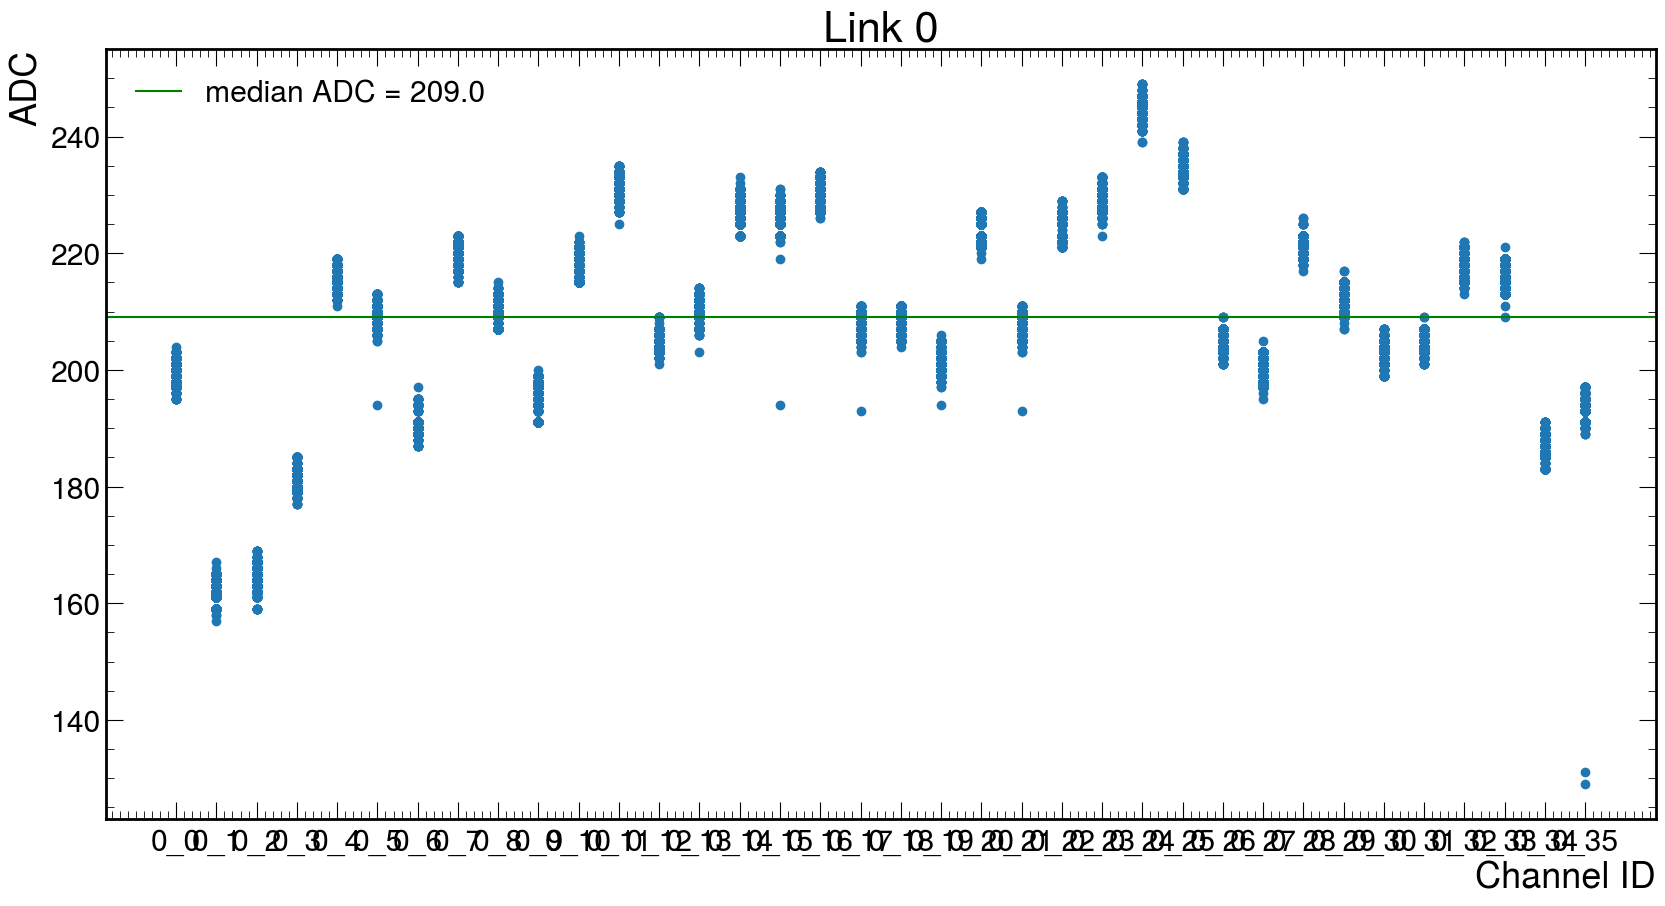

In [251]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
#plt.axhline(y=(link_0_norm['adc'].mean()), color='r', label = "mean ADC = " + str(link_0_norm['adc'].mean()) )
plt.axhline(y = (link_0_norm['adc'].median()), color = 'g', label = "median ADC = " +  str(link_0_norm['adc'].median()))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [252]:
print ("Link 1 median ADC is " + str(link_1_norm['adc'].median()) + " without calibration channels")
print ("Link 1 mean ADC is " + str(link_1_norm['adc'].mean()) + " without calibration channels")


Link 1 median ADC is 207.0 without calibration channels
Link 1 mean ADC is 209.0195361111111 without calibration channels


Text(0.5, 1.0, 'Link 1')

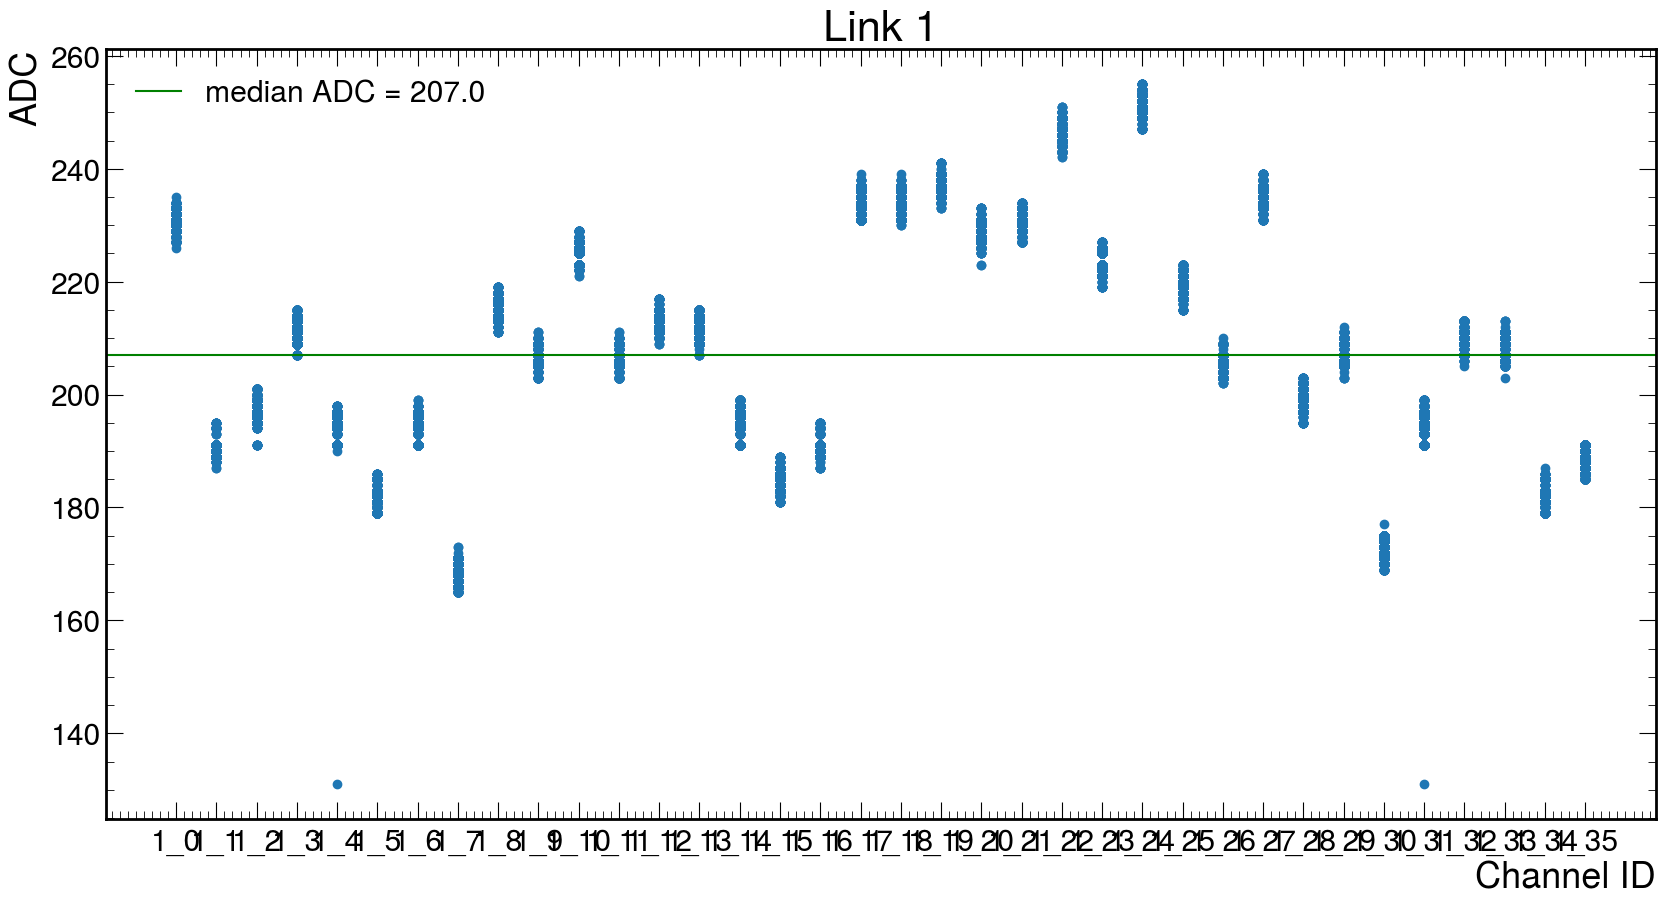

In [270]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)
#plt.axhline(y=(link_1_norm['adc'].mean()), color='r', label = "mean ADC = " + str(link_1_norm['adc'].mean()) )
plt.axhline(y = (link_1_norm['adc'].median()), color = 'g', label = "median ADC = " +  str(link_1_norm['adc'].median()))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1")

Text(0.5, 1.0, 'Link 0 channel median')

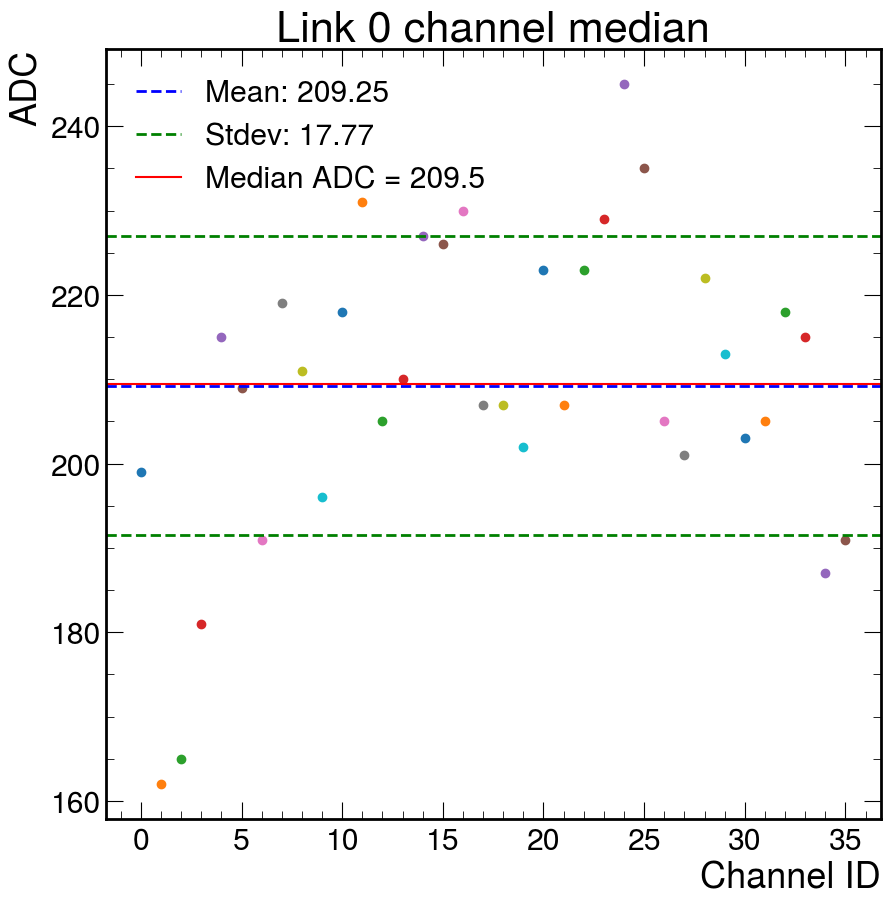

In [271]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    plt.scatter(x = i, y = median )
    l0_ch_med.append(median)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
meanVal = np.mean(l0_ch_med)
stdVal = np.std(l0_ch_med)
plt.axhline(meanVal, color='blue', linestyle='dashed', linewidth=2,
           label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)
#link_0_mean = np.mean(l0_ch_med)
#plt.axhline(y=link_0_mean, color='r', label ="Mean ADC = " + str(link_0_mean))
plt.axhline(y=link_0_median, color='r', label = "Median ADC = " + str(link_0_median))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")


Text(0.5, 1.0, 'Link 1 channel median')

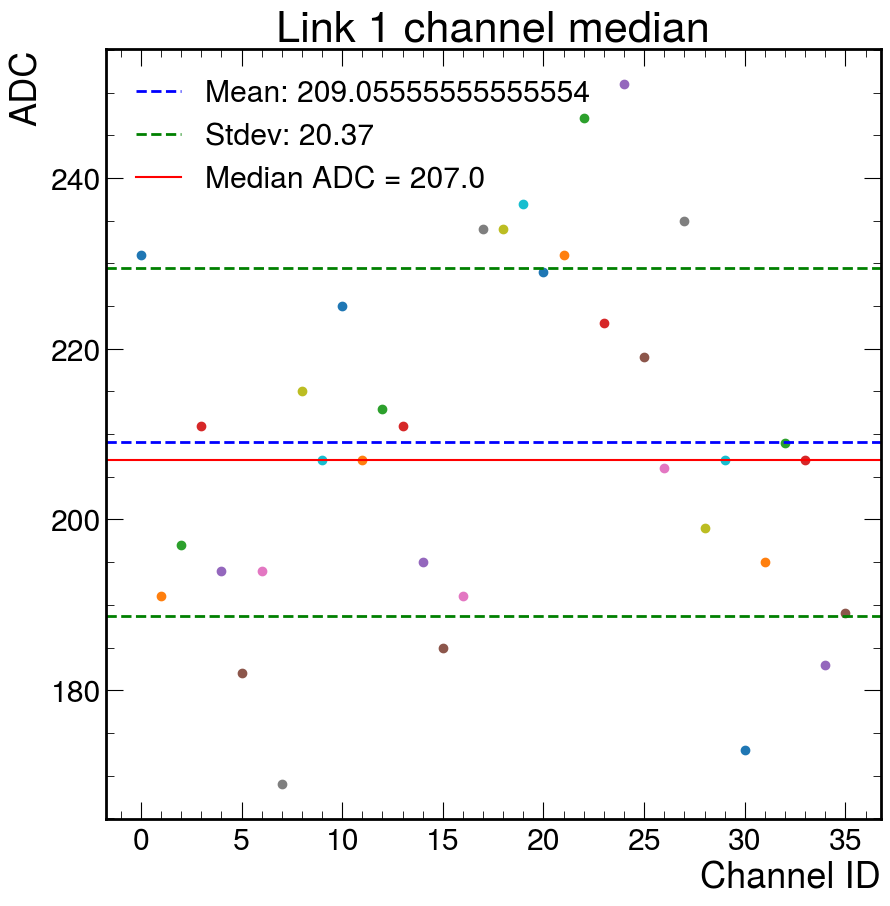

In [272]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35

for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
meanVal = np.mean(l1_ch_med)
stdVal = np.std(l1_ch_med)
plt.axhline(meanVal, color='blue', linestyle='dashed', linewidth=2,
           label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)
link_1_median= np.median(l1_ch_med) #median of the median ADC list

plt.axhline(y=link_1_median, color='r', label = "Median ADC = " + str(link_1_median))

plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")

In [273]:
high_triminv_ped = pd.read_csv('high_triminv_pedestal_10k.csv') #high trim_inv = 63, everything else is the same
high_triminv_ped['uid'] = high_triminv_ped['i_link'].astype(str)+'_'+high_triminv_ped['channel']
high_triminv_ped_norm = high_triminv_ped[high_triminv_ped['channel'] != 'calib']# removed the calibration channels to assess means/medians


In [274]:
highlink_0 = high_triminv_ped_norm[high_triminv_ped_norm['i_link'] ==0 ] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
highlink_1 = high_triminv_ped_norm[high_triminv_ped_norm['i_link'] ==1 ]



Text(0.5, 1.0, 'Link 0 channel median')

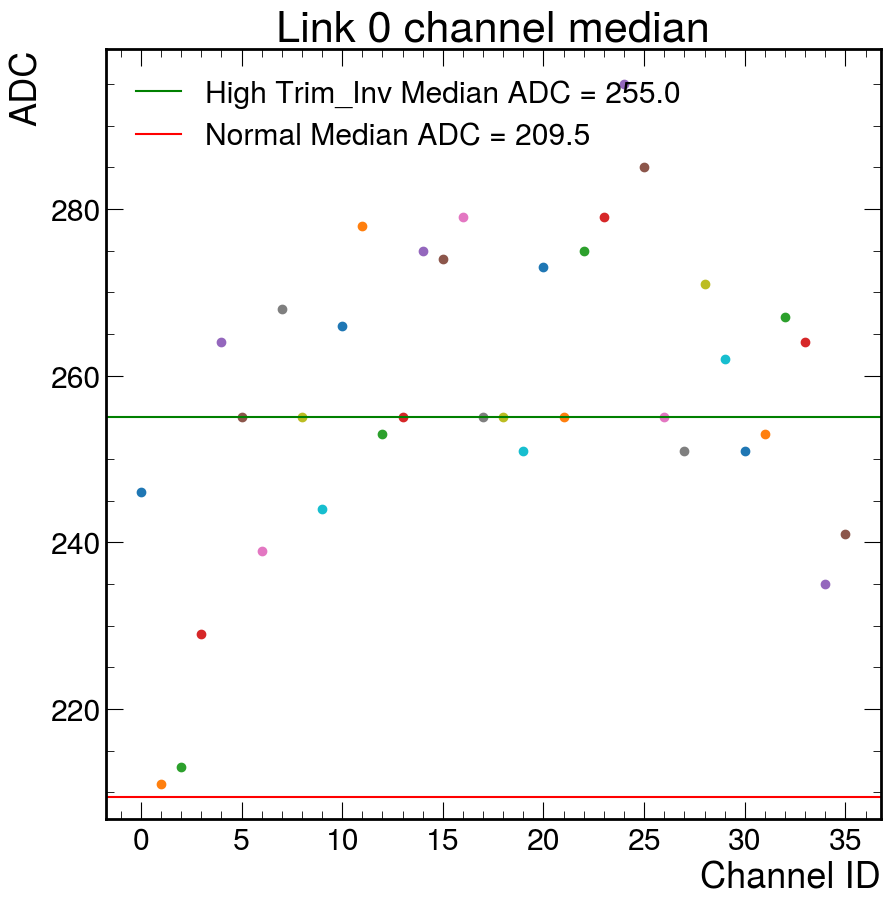

In [275]:
highlink_0_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = highlink_0[highlink_0['channel'] == str(i)]['adc'].median()
    highlink_0_med.append(median)
    plt.scatter(x = i, y = median )
highlink_0_median= np.median(highlink_0_med) #median of the median ADC list
plt.axhline(y=highlink_0_median, color='g', label = "High Trim_Inv Median ADC = " + str(highlink_0_median))
plt.axhline(y=link_0_median, color='r', label = "Normal Median ADC = " + str(link_0_median))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")


Text(0.5, 1.0, 'Link 0 channel median')

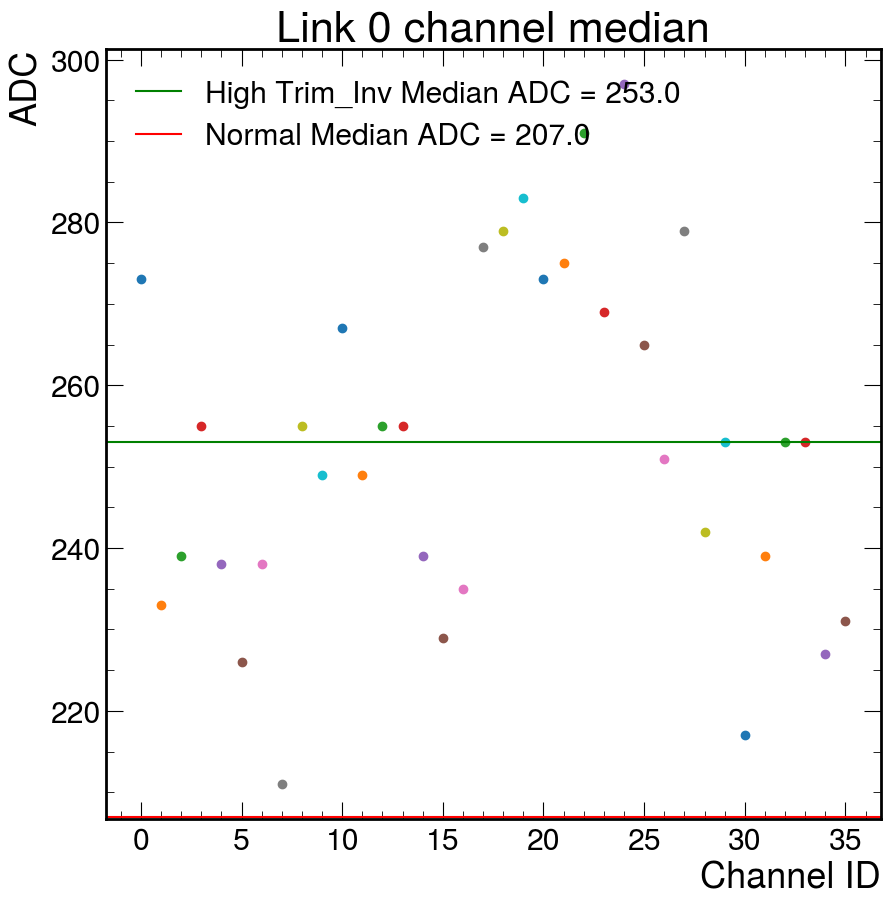

In [276]:
highlink_1_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = highlink_1[highlink_1['channel'] == str(i)]['adc'].median()
    highlink_1_med.append(median)
    plt.scatter(x = i, y = median )
highlink_1_median= np.median(highlink_1_med) #median of the median ADC list
plt.axhline(y=highlink_1_median, color='g', label = "High Trim_Inv Median ADC = " + str(highlink_1_median))
plt.axhline(y=link_1_median, color='r', label = "Normal Median ADC = " + str(link_1_median))
plt.legend(loc="upper left")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")


In [277]:
 ## i want to find the value of the parameter trim_inv when ADC is at the median, my y value is the value of the parameter, triminv, for high_trim_inv, it's 63, for low/default it's 0

In [278]:
highlink_1_med[15]

229.0

In [279]:
l1_ch_med[15]

185.0

In [280]:
### so for channel x, 
adc_values = [l1_ch_med[15],highlink_1_med[15]]
trim_inv = [0,63]
link_1_median ## evaluate at this value

207.0

In [281]:
##imagine ADC is on the x axis, im looking for the corresponding y
round(np.interp(link_1_median, adc_values, trim_inv))

32

In [282]:
neg_high_dacb_ped = pd.read_csv('neg_high_dacb_pedestal.csv') #sign_dac = 1, dacb = 31 for all channels, everything else is default
neg_high_dacb_ped['uid'] = neg_high_dacb_ped['i_link'].astype(str)+'_'+neg_high_dacb_ped['channel']
neg_high_dacb_ped = neg_high_dacb_ped[neg_high_dacb_ped['channel'] != 'calib']# removed the calibration channels to assess means/medians
dacb_link_0 = neg_high_dacb_ped[neg_high_dacb_ped['i_link'] ==0 ] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
dacb_link_1 = neg_high_dacb_ped[neg_high_dacb_ped['i_link'] ==1 ]






Text(0.5, 1.0, 'Link 0 (neg high dacb test)')

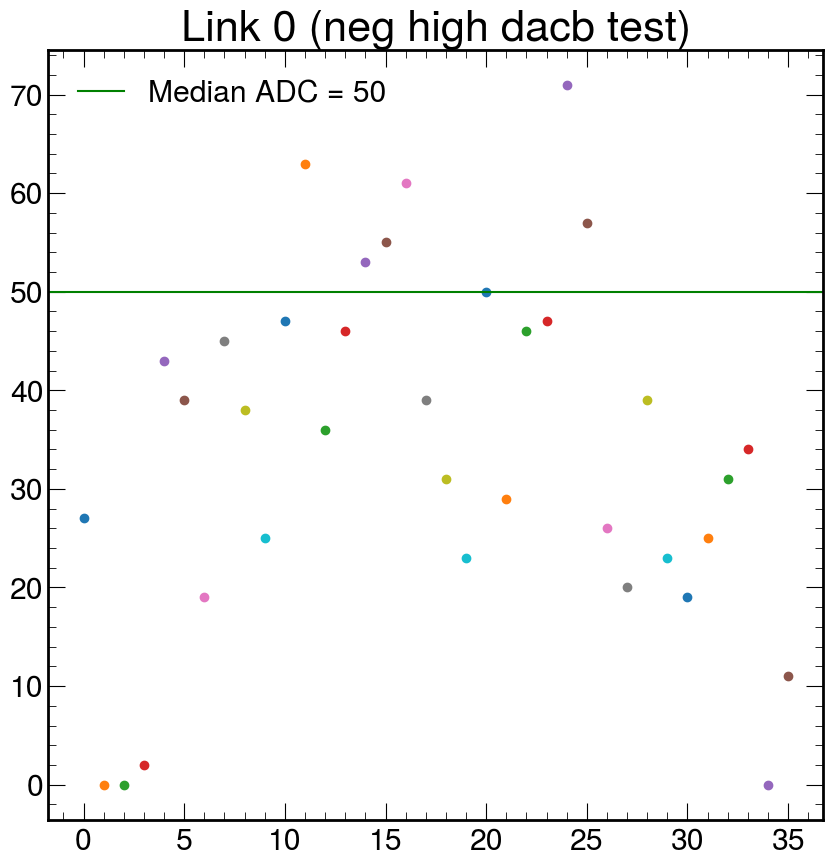

In [283]:
dacb_link_0_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = dacb_link_0[dacb_link_0['channel'] == str(i)]['adc'].median()
    dacb_link_0_med.append(median)
    plt.scatter(i, median)
plt.axhline(y=50, color='g', label = "Median ADC = " + str(50))
plt.legend(loc="best")
plt.title("Link 0 (neg high dacb test)")

Text(0.5, 1.0, 'Link 1 (neg high dacb test)')

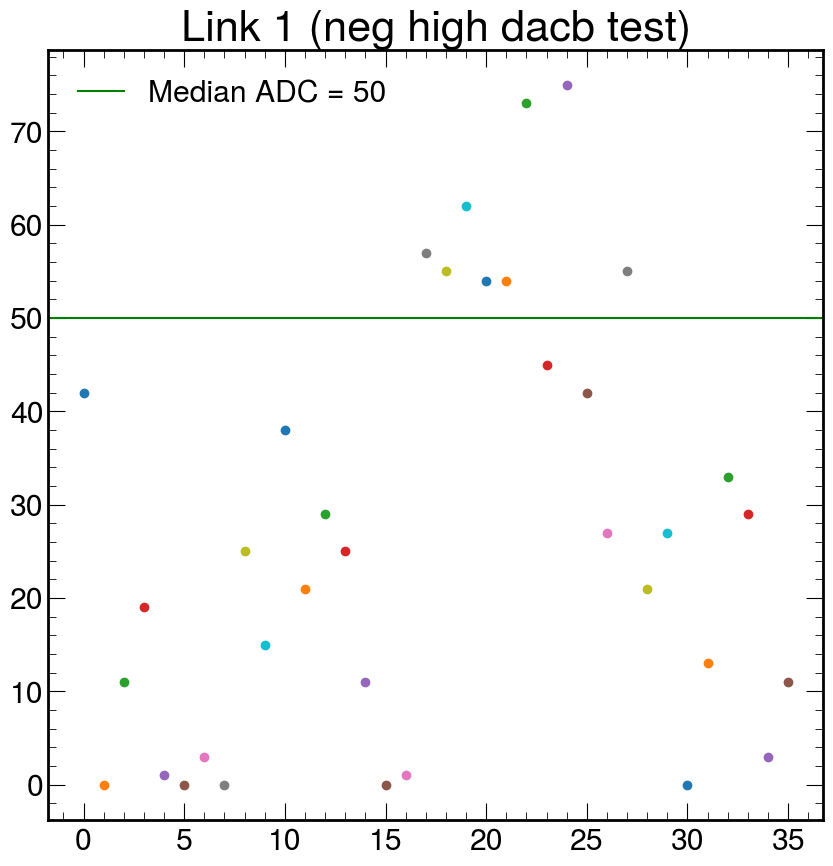

In [284]:
dacb_link_1_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = dacb_link_1[dacb_link_1['channel'] == str(i)]['adc'].median()
    dacb_link_1_med.append(median)
    plt.scatter(i,median)
#plt.axhline(y=link_1_median, color='g', label = "Median ADC = " + str(link_1_median))
plt.axhline(y=50, color='g', label = "Median ADC = " + str(50))
plt.legend(loc="best")
plt.title("Link 1 (neg high dacb test)")
    

In [285]:
adc_values = [dacb_link_1_med[26],l1_ch_med[26]]
dacb = [31,0]
link_0_median ## evaluate at this value


209.5

In [286]:
adc_values = [dacb_link_0_med[7],l0_ch_med[7]]
dacb = [31,0]
link_0_median ## evaluate at this value


209.5

In [79]:
channels_settings_med50 = {}
#default_triminv= 0
#default_dacb = 0
#default_sign_dac = 0
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [31,0]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < 50 :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(50, adc_values, trim_inv))
        channels_settings_med50[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_0_med[a], l0_ch_med[a]]
        new_dacb = round(np.interp(50, adc_values, dacb))
        channels_settings_med50[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < 50 :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(50, adc_values, trim_inv))
        channels_settings_med50[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(50, adc_values, dacb))
        channels_settings_med50[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
            

In [224]:
channels_settings_med_75 = {}
#default_triminv= 0
#default_dacb = 0
#default_sign_dac = 0
median =75 # trying for a median at 100 instead
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [31,0]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < 75 :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(median, adc_values, trim_inv))
        channels_settings_med_75[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_0_med[a], l0_ch_med[a]]
        new_dacb = round(np.interp(median, adc_values, dacb))
        channels_settings_med_75[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < 75 :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(median, adc_values, trim_inv))
        channels_settings_med_75[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(median, adc_values, dacb))
        channels_settings_med_75[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
channels_settings_med_75['REFERENCEVOLTAGE_0'] ={'INV_VREF' : 416}
channels_settings_med_75['REFERENCEVOLTAGE_1'] ={'INV_VREF' : 416}
            

In [223]:
adc_values = [dacb_link_0_med[4], l0_ch_med[4]]
adc_values


[43.0, 215.0]

In [ ]:
new_dacb = round(np.interp(median, adc_values, dacb))
print(new_dacb)

In [235]:
dacb_link_1_med[20]

54.0

In [239]:
for i in dacb_link_1_med:
    if i > 75:
        #print (i)
        #ch_no = 36 +dacb_link_0_med.index(i)
        print("Channel " + str(36 + dacb_link_1_med.index(i)) +" has an ADC of " +str(i))

In [240]:
with open ('med_75_channel_settings.yaml', 'w') as f:
    yaml.dump(channels_settings_med_75, f)

In [287]:
channels_settings_med_100 = {}
#default_triminv= 0
#default_dacb = 0
#default_sign_dac = 0
median = 100 # trying for a median at 100 instead
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [31,0]
inv_vref = [416,540]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < median :
        adc_values = [l0_ch_med[a],high_inv_vref_link_0_med[a]]
        new_inv = round(np.interp(median, adc_values, trim_inv))
        channels_settings_med_100[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_0_med[a], l0_ch_med[a]]
        new_dacb = round(np.interp(median, adc_values, dacb))
        channels_settings_med_100[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < median :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(median, adc_values, trim_inv))
        channels_settings_med_100[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(median, adc_values, dacb))
        channels_settings_med_100[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
channels_settings_med_100['REFERENCEVOLTAGE_0'] ={'INV_VREF' : 416}
channels_settings_med_100['REFERENCEVOLTAGE_1'] ={'INV_VREF' : 416}
            

In [288]:
with open ('med_100_channel_settings.yaml', 'w') as f:
    yaml.dump(channels_settings_med_100, f)

In [225]:
channels_settings_med_100


{'CH_0': {'DACB': 22, 'SIGN_DAC': 1},
 'CH_1': {'DACB': 17, 'SIGN_DAC': 1},
 'CH_2': {'DACB': 17, 'SIGN_DAC': 1},
 'CH_3': {'DACB': 18, 'SIGN_DAC': 1},
 'CH_4': {'DACB': 25, 'SIGN_DAC': 1},
 'CH_5': {'DACB': 24, 'SIGN_DAC': 1},
 'CH_6': {'DACB': 21, 'SIGN_DAC': 1},
 'CH_7': {'DACB': 26, 'SIGN_DAC': 1},
 'CH_8': {'DACB': 24, 'SIGN_DAC': 1},
 'CH_9': {'DACB': 22, 'SIGN_DAC': 1},
 'CH_10': {'DACB': 26, 'SIGN_DAC': 1},
 'CH_11': {'DACB': 29, 'SIGN_DAC': 1},
 'CH_12': {'DACB': 24, 'SIGN_DAC': 1},
 'CH_13': {'DACB': 26, 'SIGN_DAC': 1},
 'CH_14': {'DACB': 27, 'SIGN_DAC': 1},
 'CH_15': {'DACB': 27, 'SIGN_DAC': 1},
 'CH_16': {'DACB': 28, 'SIGN_DAC': 1},
 'CH_17': {'DACB': 24, 'SIGN_DAC': 1},
 'CH_18': {'DACB': 23, 'SIGN_DAC': 1},
 'CH_19': {'DACB': 22, 'SIGN_DAC': 1},
 'CH_20': {'DACB': 27, 'SIGN_DAC': 1},
 'CH_21': {'DACB': 23, 'SIGN_DAC': 1},
 'CH_22': {'DACB': 26, 'SIGN_DAC': 1},
 'CH_23': {'DACB': 26, 'SIGN_DAC': 1},
 'CH_24': {'DACB': 30, 'SIGN_DAC': 1},
 'CH_25': {'DACB': 28, 'SIGN_DAC': 

In [32]:
#with open ('aligned_dacb_trim_inv_settings_v3.yaml', 'w') as f:
    #yaml.dump(channels_settings, f)

Visualization of Version 3 that worked well

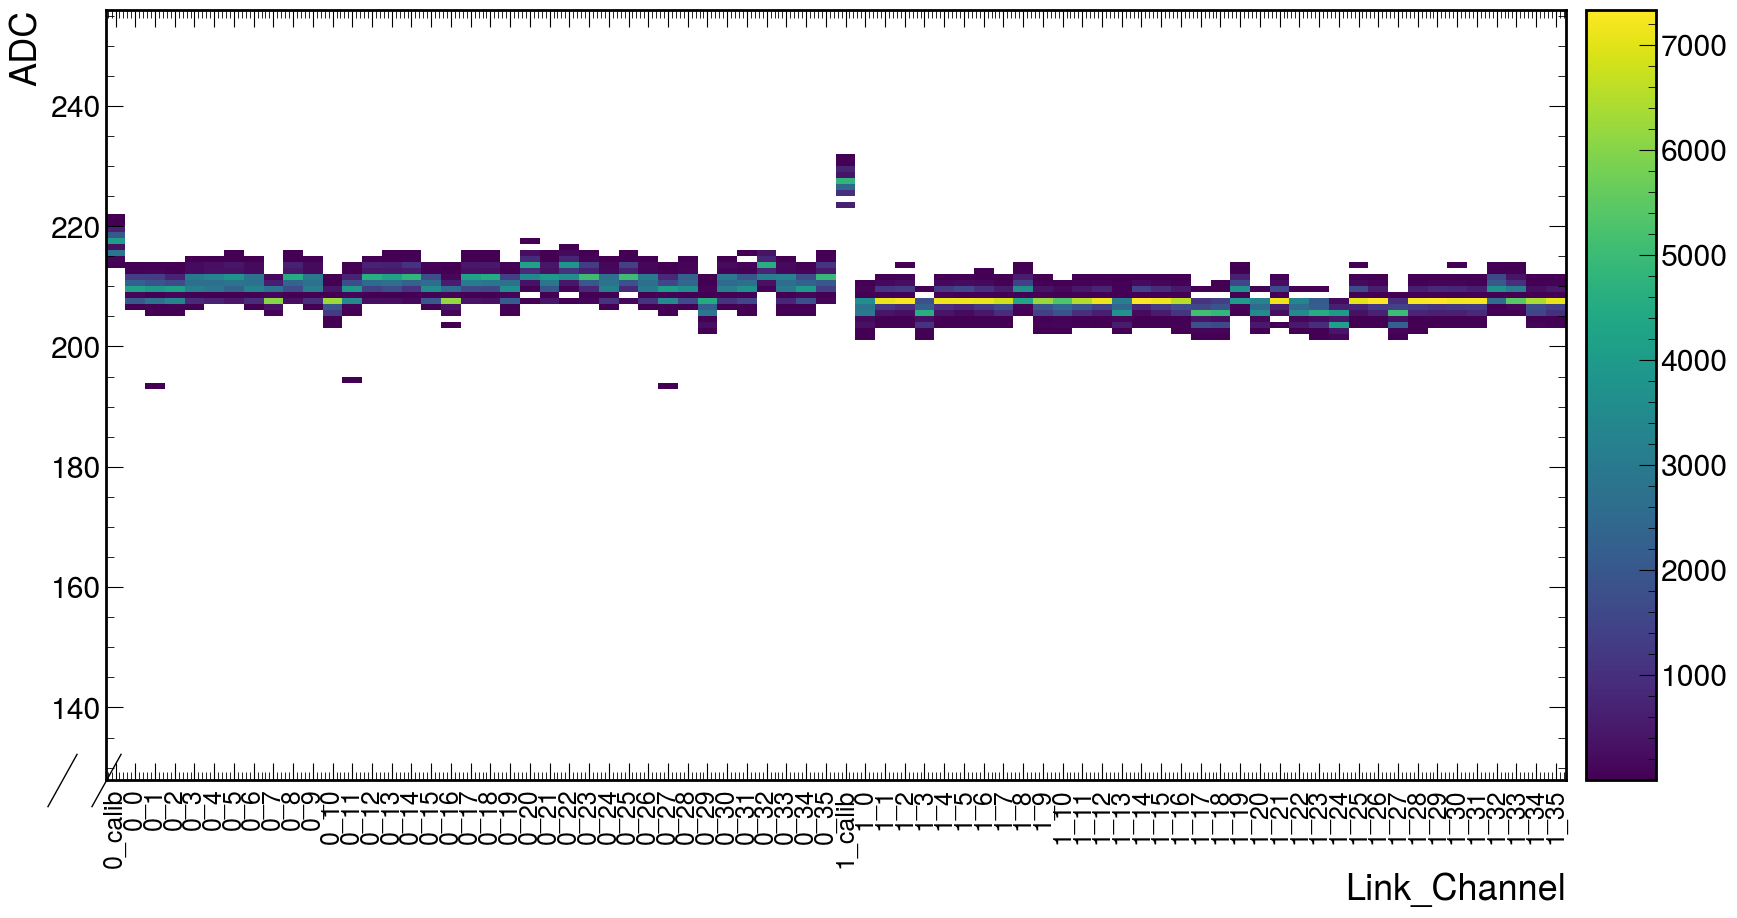

In [61]:
## version 3 has worked 
pedestal = pd.read_csv('align_ped_10k_v3.csv')
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']
fill_and_plot_all_channels('adc','ADC',128,256)

In [62]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']

Text(0.5, 1.0, 'Link 0 channel median')

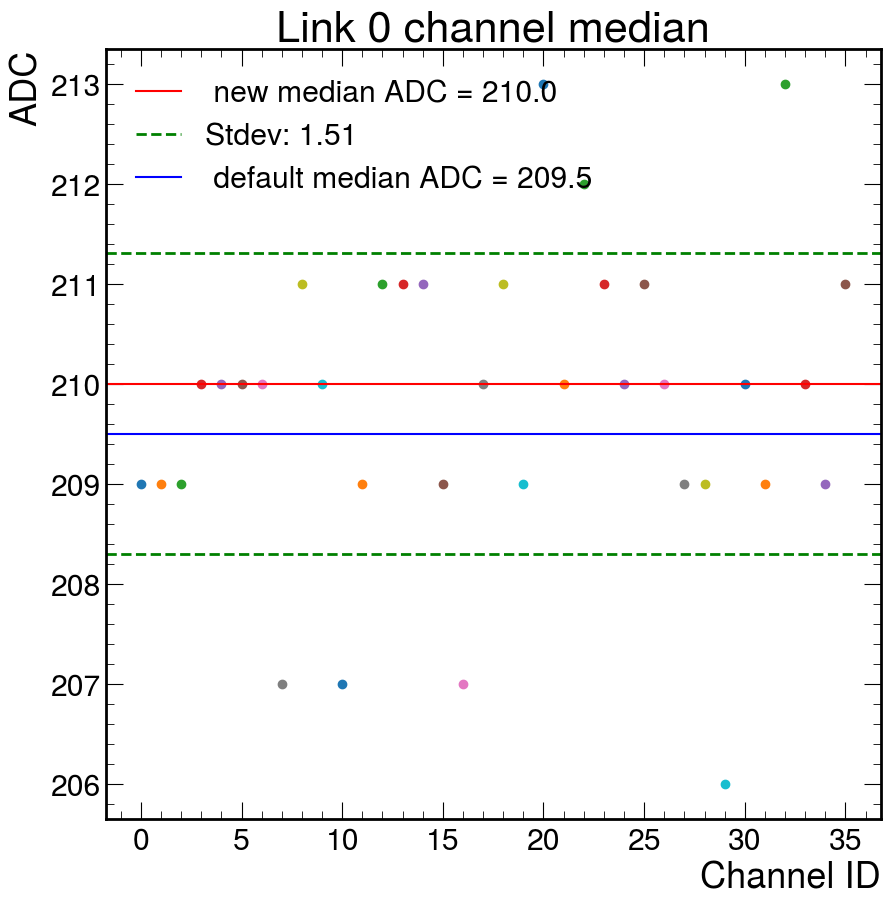

In [66]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    plt.scatter(x = i, y = median )
    l0_ch_med.append(median)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
plt.axhline(y = link_0_median, color = 'r', label = " new median ADC = "+str(link_0_median))
meanVal = np.mean(l0_ch_med)
stdVal = np.std(l0_ch_med)
#plt.axhline(meanVal, color='blue', linestyle='dashed', linewidth=2,label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)
plt.axhline(y = 209.5, color = 'b', label = " default median ADC = 209.5")
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")


Text(0.5, 1.0, 'Link 1 channel median')

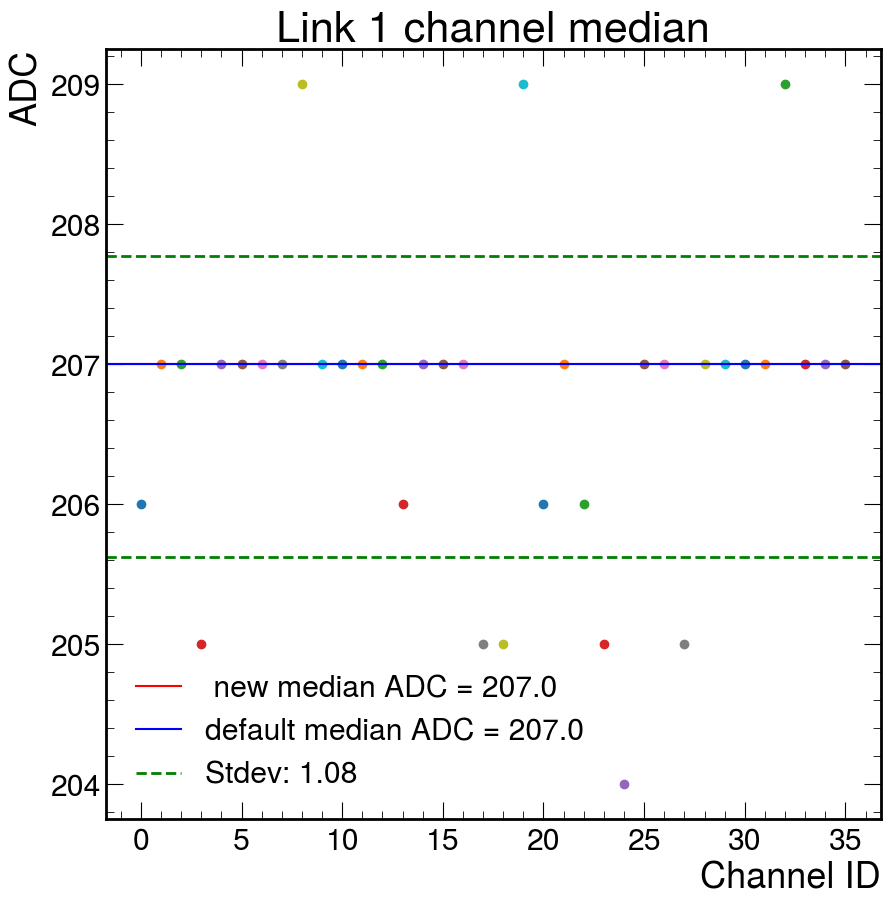

In [69]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+ str(link_1_median))
plt.axhline(y = 207.0, color = 'b', label = "default median ADC = 207.0")
meanVal = np.mean(l1_ch_med)
stdVal = np.std(l1_ch_med)
plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)

plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")

In [45]:
inv_vref_test[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
1221,510,False,False,51,50,-1,0
1222,510,False,False,53,50,-1,0
1223,510,False,False,51,51,-1,0
1224,510,False,False,49,49,-1,0
1228,510,False,False,51,51,-1,0
1229,510,False,False,51,51,-1,0
1230,511,False,False,51,50,-1,0
1231,511,False,False,51,50,-1,0
1232,511,False,False,50,50,-1,0
1233,511,False,False,51,49,-1,0


In [46]:
np.round(mean(list(inv_vref_test.INV_VREF[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]))) #LINK 1 mean inv_vref that'll give us 50 +/- 1 for adc

512.0

In [75]:
# {"parameter_points_file":"link_1_noinv_vref_scan_setting.csv","channel":71,"nevents_per_point":1,"trigger":"PEDESTAL","scan_wide_params":{}}REFERENCEVOLTAGE_1.NOINV_VREF
noinv_vref_test = pd.read_csv('link_1_noinv_vref_scan_setting_20250707_192923.csv')

Text(0, 1, 'ADC')

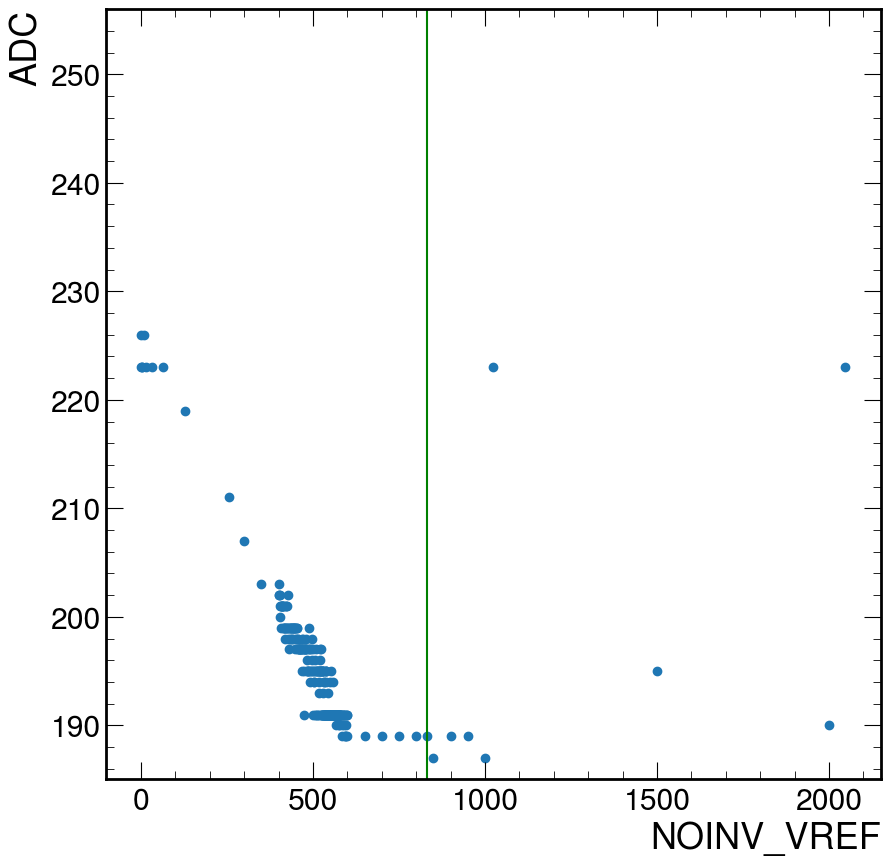

In [90]:
plt.scatter(noinv_vref_test.NOINV_VREF, noinv_vref_test.adc)
#plt.axhline(y=200, color='g')
plt.axvline(x=832, color='g')
plt.ylim(top = 256)
#plt.xlim(left = 500)
plt.xlabel("NOINV_VREF")
plt.ylabel("ADC")

In [94]:
noinv_vref_test[(noinv_vref_test.adc>=206) & (noinv_vref_test.adc <=208)]

,NOINV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
10,300,False,False,207,207,-1,0


In [91]:
np.round(mean(list(noinv_vref_test.NOINV_VREF[(noinv_vref_test.adc>=206) & (noinv_vref_test.adc <=208)])))

300

In [95]:
# {"parameter_points_file":"link_1_inv_vref_scan_setting.csv","channel":71,"nevents_per_point":1,"trigger":"PEDESTAL","scan_wide_params":{"REFERENCEVOLTAGE_1":{"NOINV_VREF":300}}}
#REFERENCEVOLTAGE_1.INV_VREF,
test = pd.read_csv('link_1_inv_vref_scan_setting_20250707_200426.csv')

Text(0, 1, 'ADC')

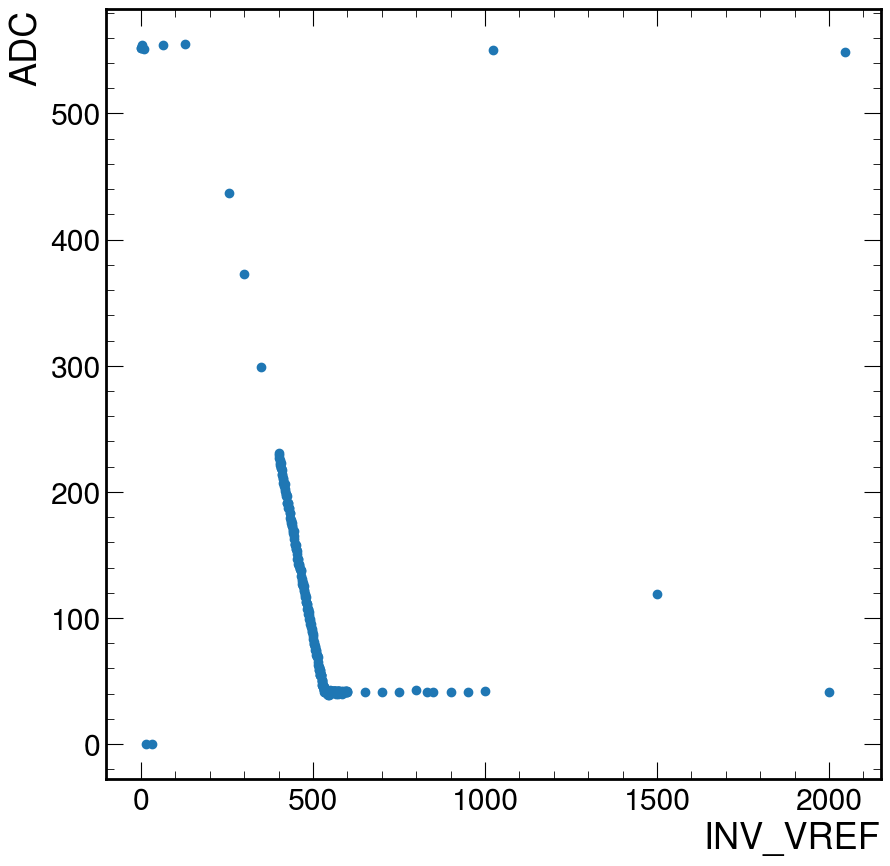

In [96]:
plt.scatter(test.INV_VREF, test.adc)
#plt.axhline(y=200, color='g')
#plt.axvline(x=832, color='g')
#plt.ylim(top = 256)
#plt.xlim(left = 500)
plt.xlabel("INV_VREF")
plt.ylabel("ADC")

In [97]:
test[(test.adc>=49) & (test.adc <=51)]

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
137,525,False,False,53,51,-1,0
138,526,False,False,51,50,-1,0
197,525,False,False,51,51,-1,0
198,526,False,False,50,49,-1,0


In [48]:
channels_settings['REFERENCEVOLTAGE_0'] ={'INV_VREF' : 520}
channels_settings['REFERENCEVOLTAGE_1'] ={'INV_VREF' : 512}

In [50]:
#with open ('vref_settings_v4.yaml', 'w') as f:
    yaml.dump(channels_settings, f)

In [29]:
high_inv_vref_ped = pd.read_csv('high_inv_vref_ped_med_50.csv') #high inv_vref = 530, pedestal has already been leveled to 50
high_inv_vref_ped['uid'] = high_inv_vref_ped['i_link'].astype(str)+'_'+high_inv_vref_ped['channel']
high_inv_vref_ped_norm = high_inv_vref_ped[high_inv_vref_ped['channel'] != 'calib']# removed the calibration channels to assess means/medians
high_inv_vref_link_0 = high_inv_vref_ped_norm[high_inv_vref_ped_norm['i_link'] ==0 ] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
high_inv_vref_link_1 = high_inv_vref_ped_norm[high_inv_vref_ped_norm['i_link'] ==1 ]




Text(0.5, 1.0, 'Link 0')

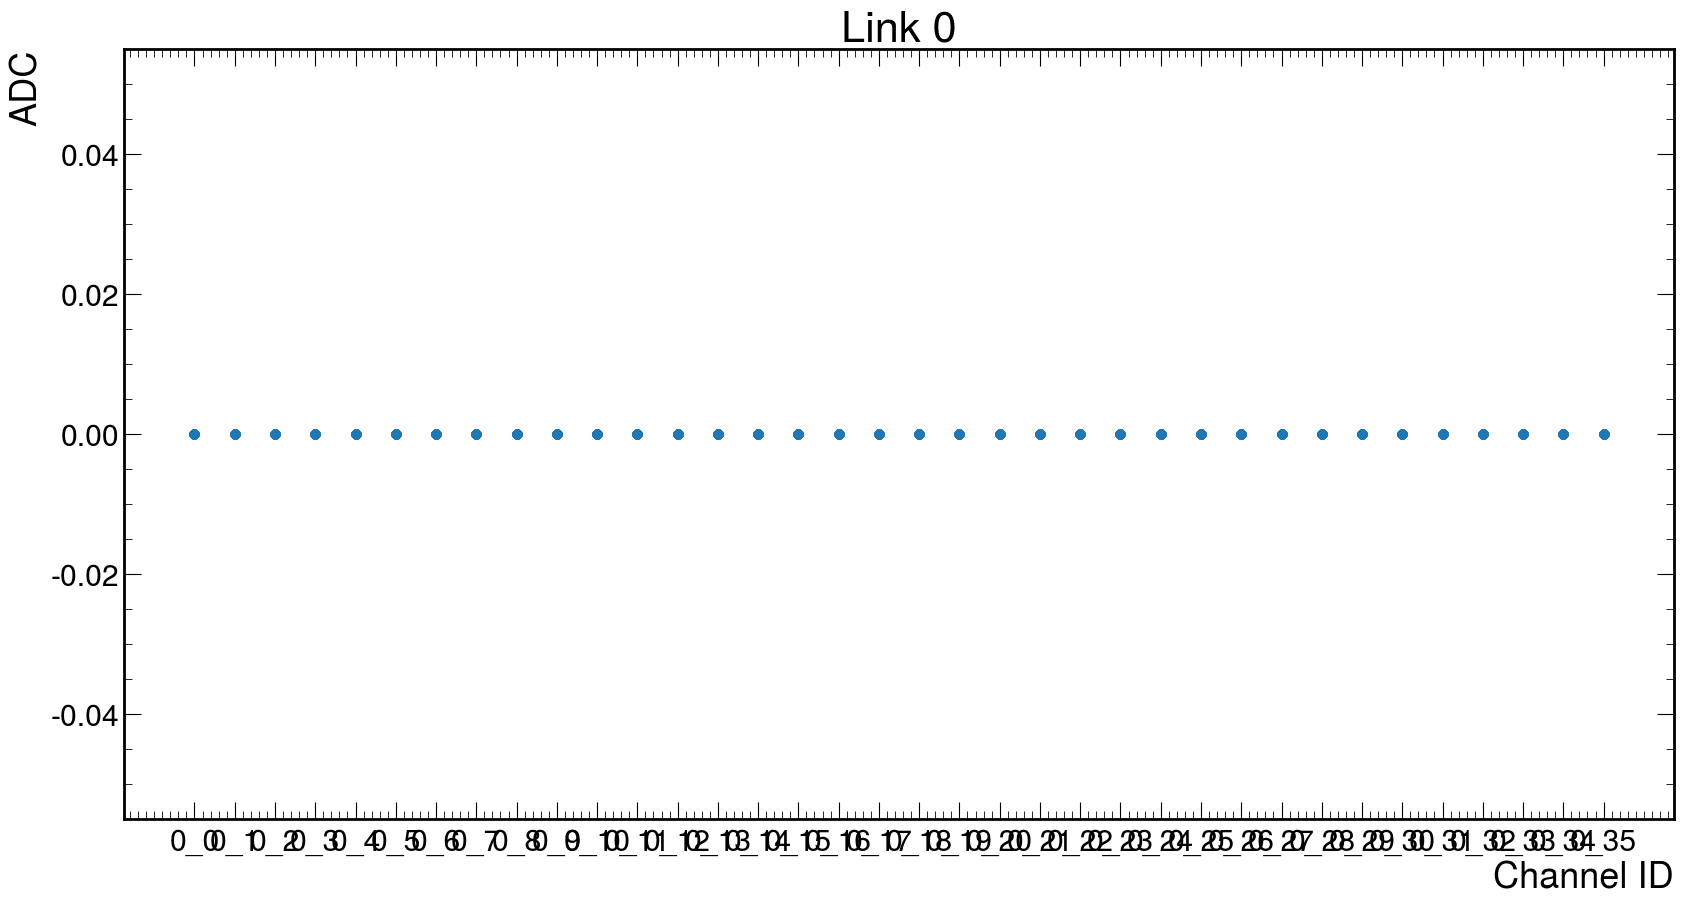

In [30]:
plt.figure(figsize=(20,10))
plt.scatter(high_inv_vref_link_0.uid,high_inv_vref_link_0.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

Text(0.5, 1.0, 'Link 0 channel median')

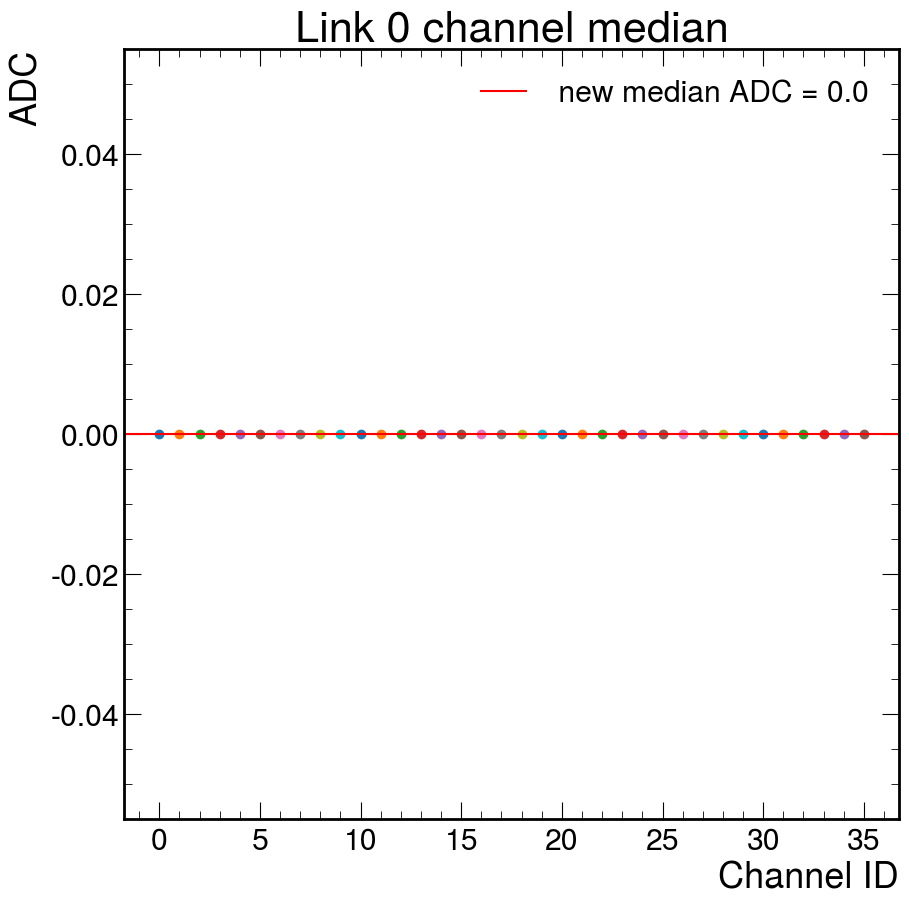

In [31]:
high_inv_vref_l0_med = [] #the median ADC of each channel, in order from 0 to 35
#l0_ch_stddev = []
for i in range(36):
    median = high_inv_vref_link_0[high_inv_vref_link_0['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    high_inv_vref_l0_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
high_inv_vref_link_0_median= np.median(high_inv_vref_l0_med) #median of the median ADC list
plt.axhline(y = high_inv_vref_link_0_median, color = 'r', label = " new median ADC = "+str(high_inv_vref_link_0_median))
#plt.axhline(y = 209.5, color = 'g', label = " default median ADC = 209.5")
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")

Text(0.5, 1.0, 'Link 1 channel median')

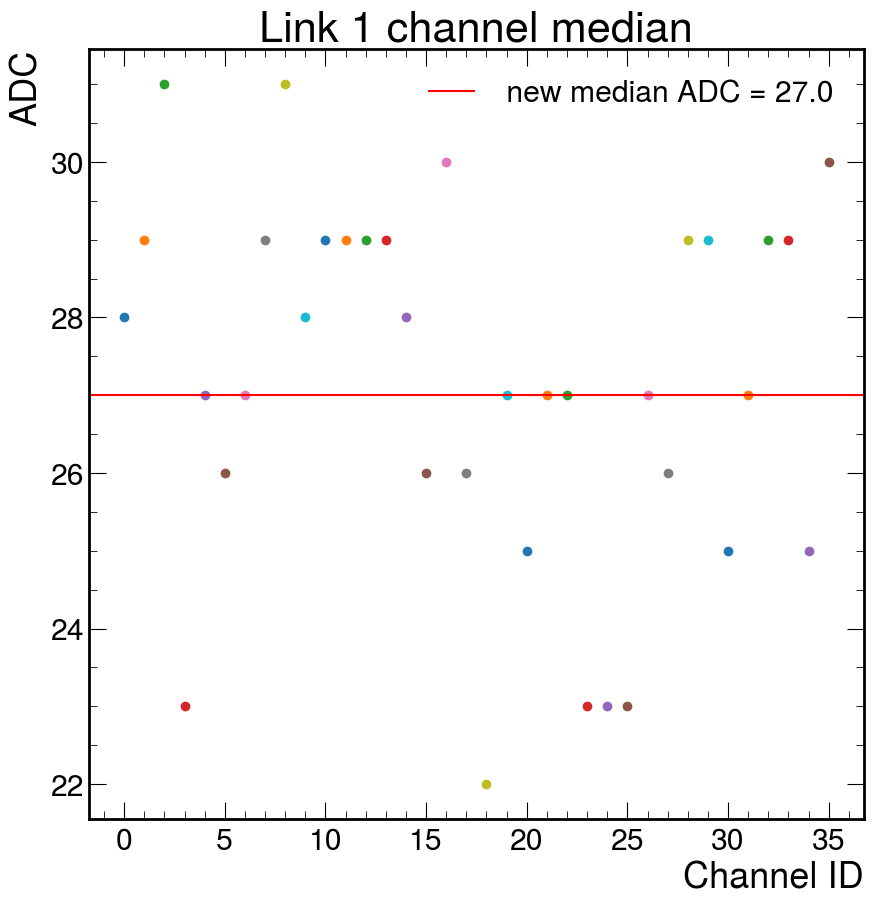

In [9]:
high_inv_vref_l1_med = [] #the median ADC of each channel, in order from 0 to 35
#l0_ch_stddev = []
for i in range(36):
    median = high_inv_vref_link_1[high_inv_vref_link_1['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    high_inv_vref_l1_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
high_inv_vref_link_1_median= np.median(high_inv_vref_l1_med) #median of the median ADC list
plt.axhline(y = high_inv_vref_link_1_median, color = 'r', label = " new median ADC = "+str(high_inv_vref_link_1_median))
#plt.axhline(y = 209.5, color = 'g', label = " default median ADC = 209.5")
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")

In [14]:
high_inv_vref_link_1_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = high_inv_vref_link_1[high_inv_vref_link_1['channel'] == str(i)]['adc'].median()
    high_inv_vref_link_1_med.append(median)

In [13]:
adc_values = [high_inv_vref_link_1_med[26],l1_ch_med[26]]
inv_vref = [540,416]
link_0_median ## evaluate at this value
round(np.interp(50, adc_values, inv_vref))

NameError: name 'high_inv_vref_link_1_med' is not defined

In [132]:
pedestal = pd.read_csv('pedestal_20250728_165551.csv') ##i adjusted the inv_vref values to 526, shifting the median down, no adjusting to trim_inv & dacb yet

In [133]:
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [134]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

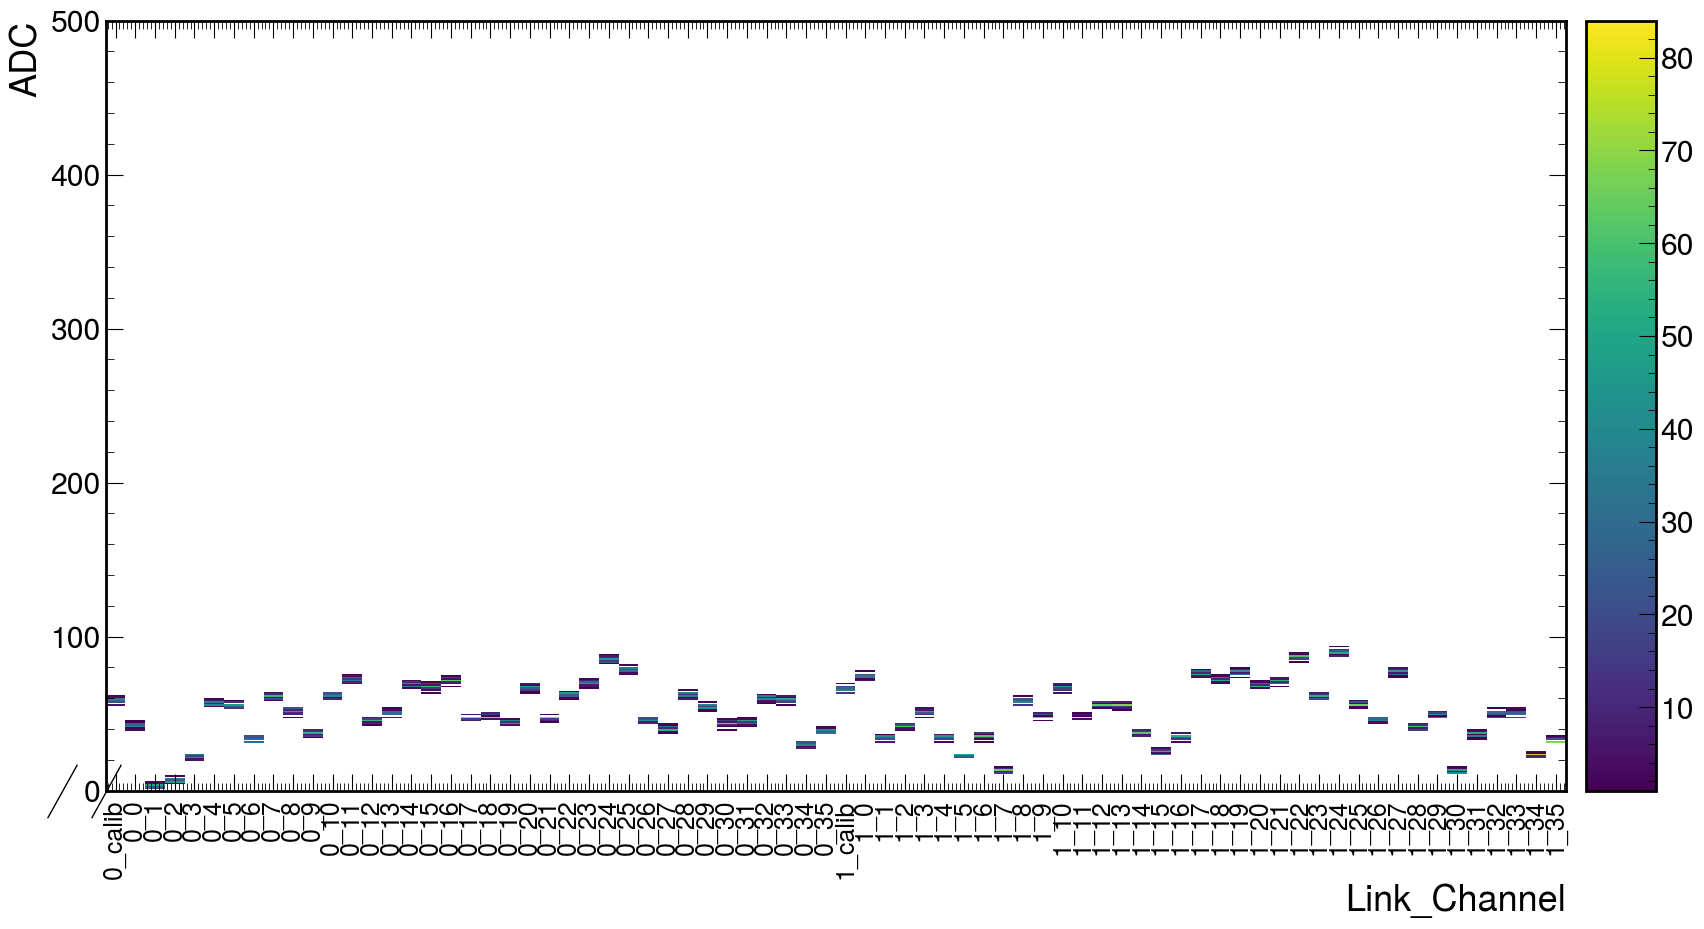

In [135]:
fill_and_plot_all_channels('adc','ADC',0,500)

In [136]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']


Text(0, 1, 'ADC')

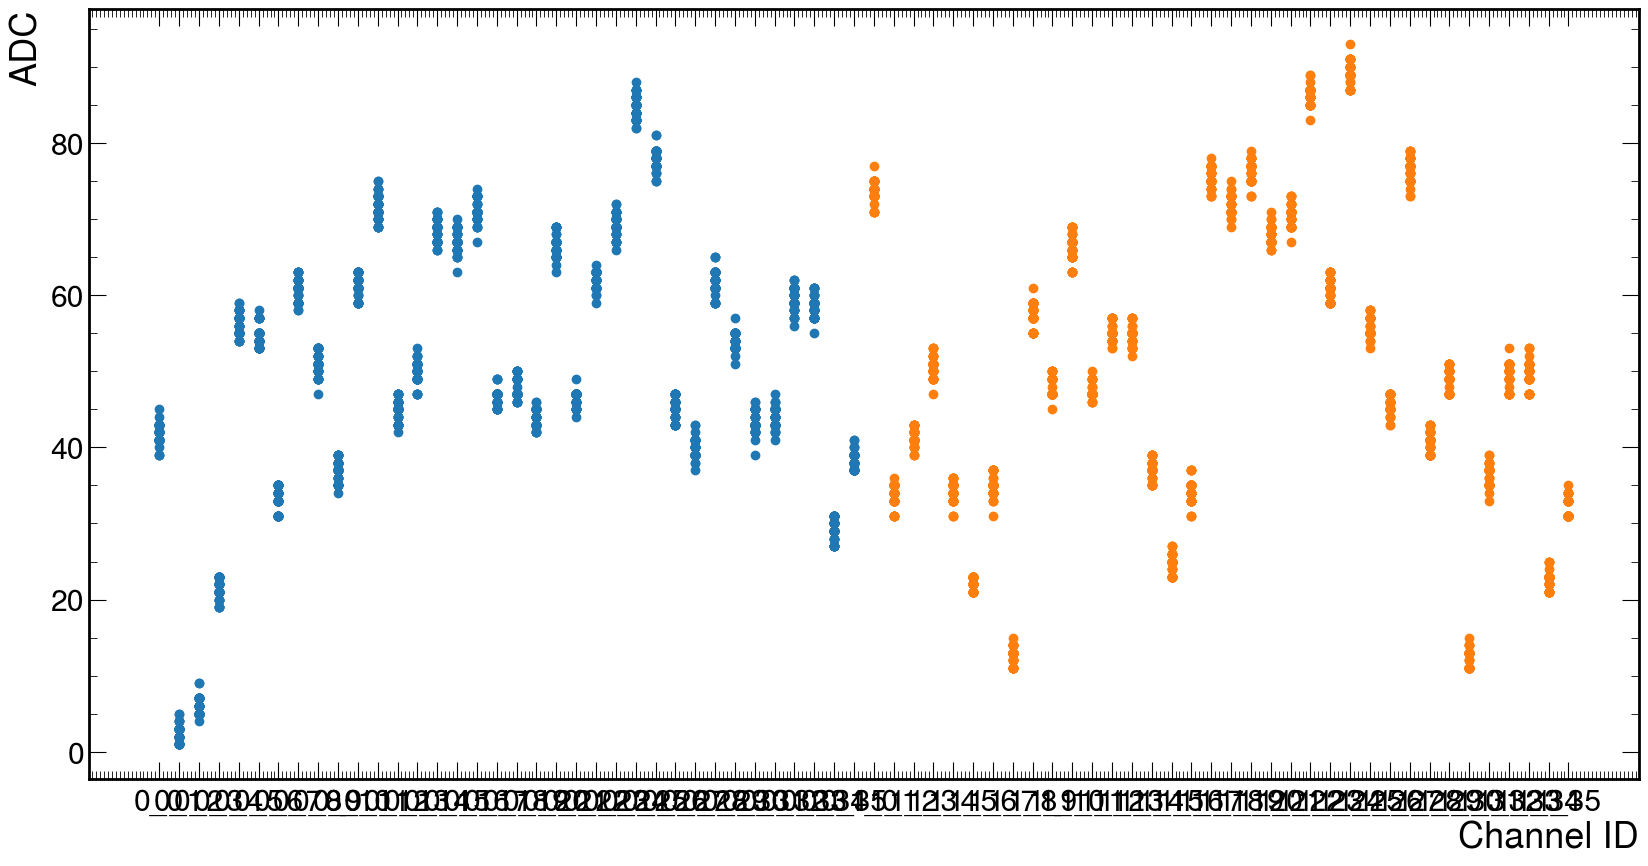

In [137]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.scatter(link_1_norm.uid, link_1_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")

Text(0.5, 1.0, 'Link 0 channel median')

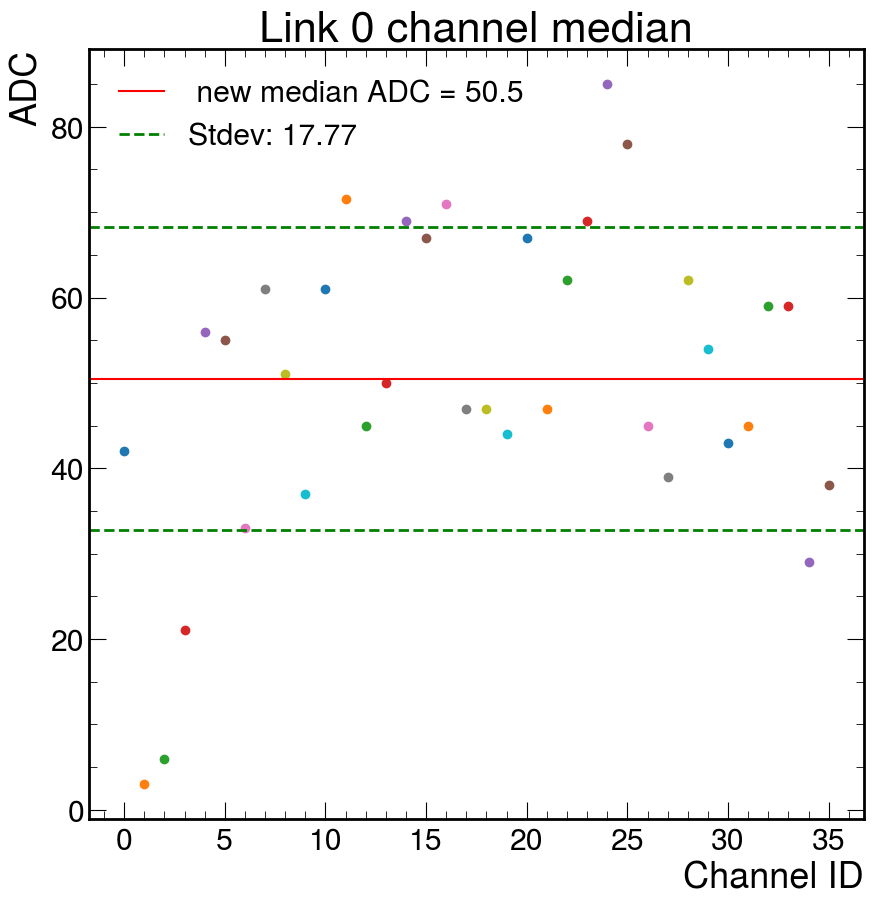

In [138]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    plt.scatter( x = i, y = median)
    l0_ch_med.append(median)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
plt.axhline(y = link_0_median, color = 'r', label = " new median ADC = "+str(link_0_median))
#plt.axhline(y = 209.5, color = 'b', label = " default median ADC = 209.5")
meanVal = np.mean(l0_ch_med)
stdVal = np.std(l0_ch_med)
#plt.axhline(meanVal, color='blue', linestyle='dashed', linewidth=2,label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)

plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")

Text(0.5, 1.0, 'Link 1 channel median')

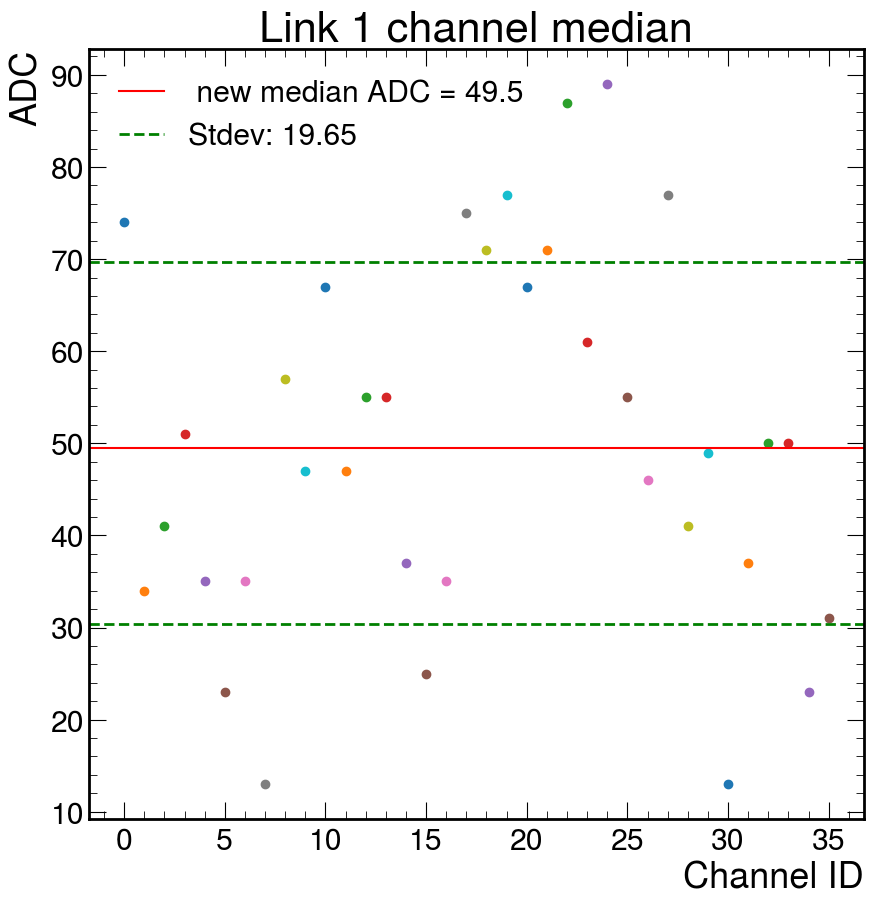

In [139]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    plt.scatter( x = i, y = median)
    l1_ch_med.append(median)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+str(link_1_median))
meanVal = np.mean(l1_ch_med)
stdVal = np.std(l1_ch_med)
#plt.axhline(meanVal, color='black', linestyle='dashed', linewidth=2,label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)

plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")


In [156]:
pedestal = pd.read_csv('pedestal_med50_leveled.csv') #leveled pedestal after setting inv_vref = 526

In [157]:
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [158]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

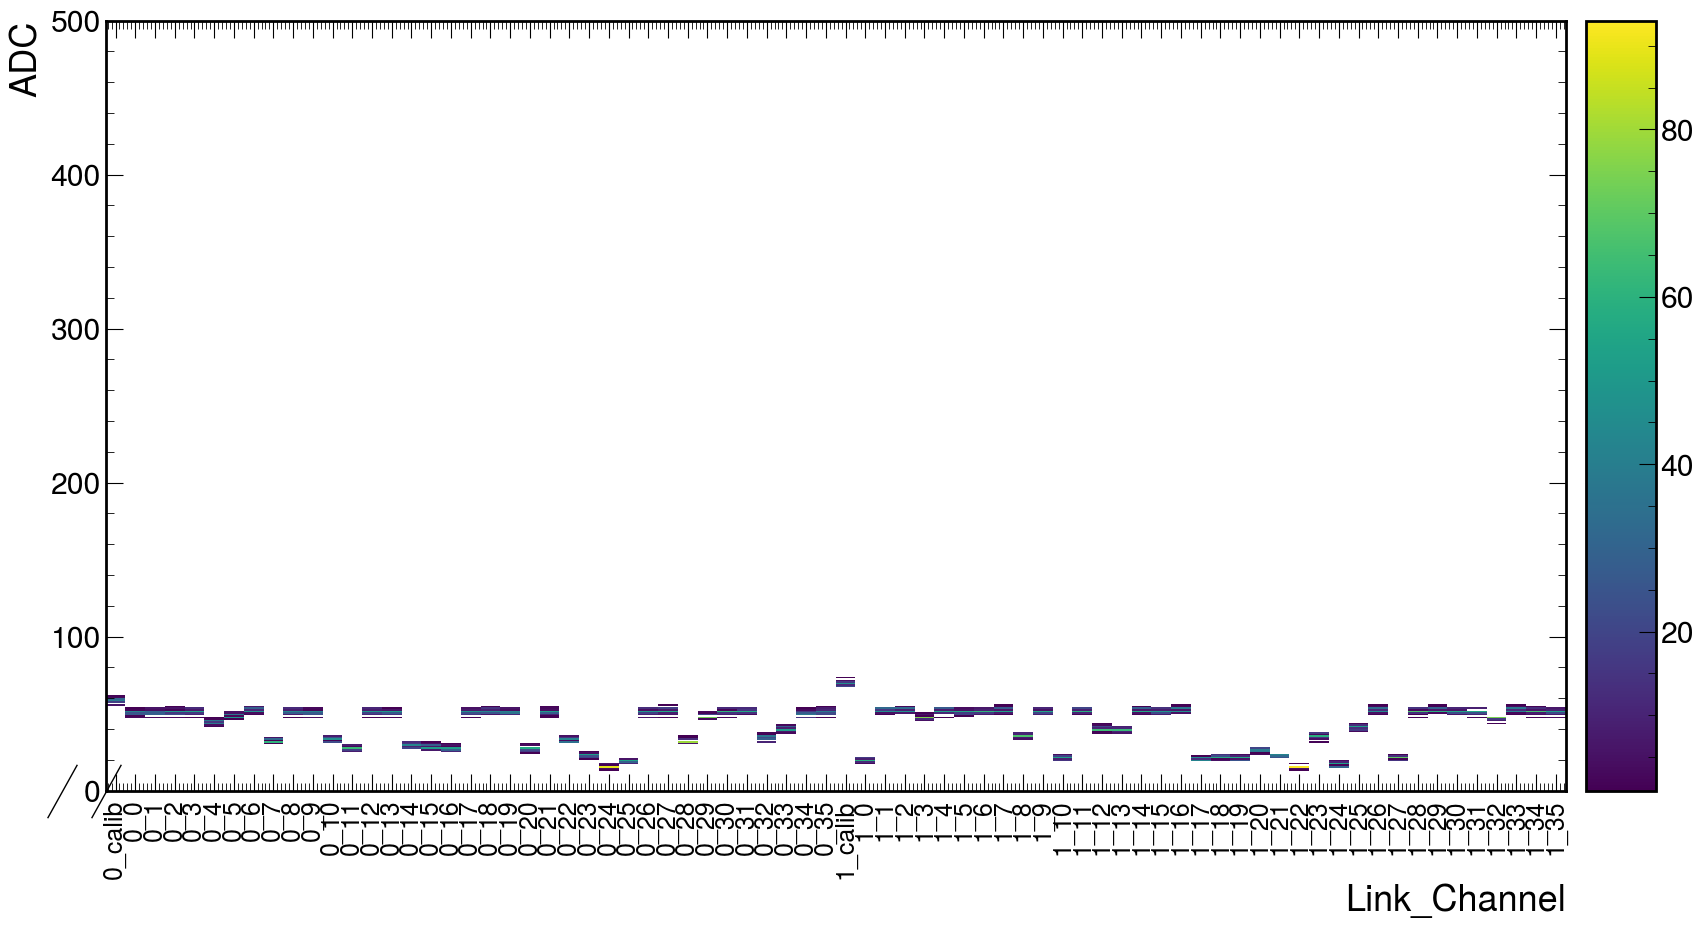

In [159]:
fill_and_plot_all_channels('adc','ADC',0,500)

In [160]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']


Text(0, 1, 'ADC')

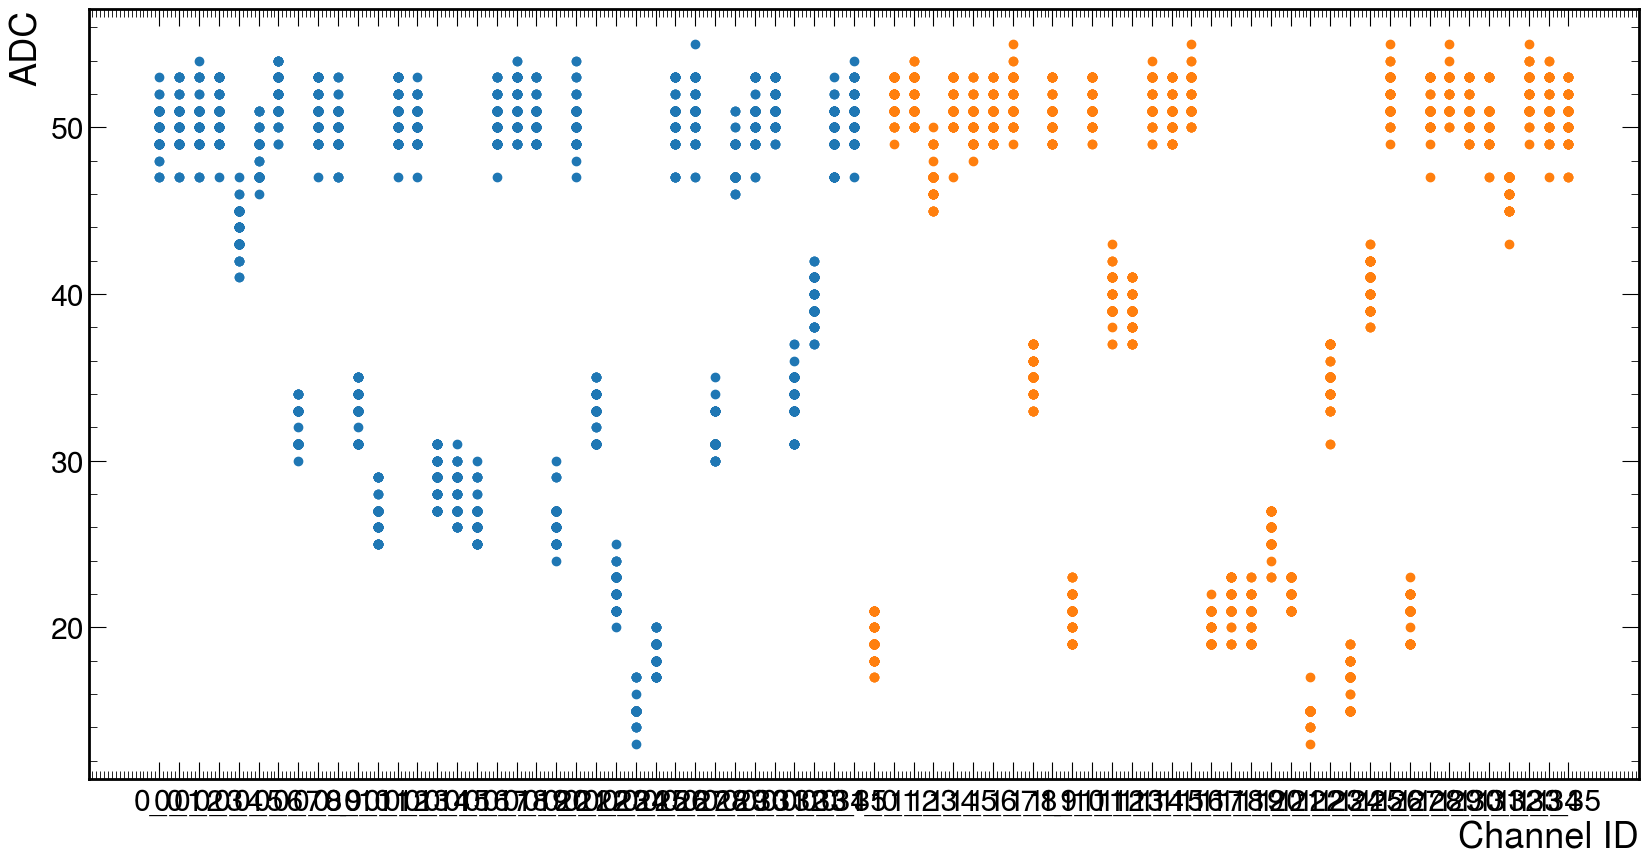

In [161]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.scatter(link_1_norm.uid, link_1_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")

Text(0.5, 1.0, 'Link 0 channel median')

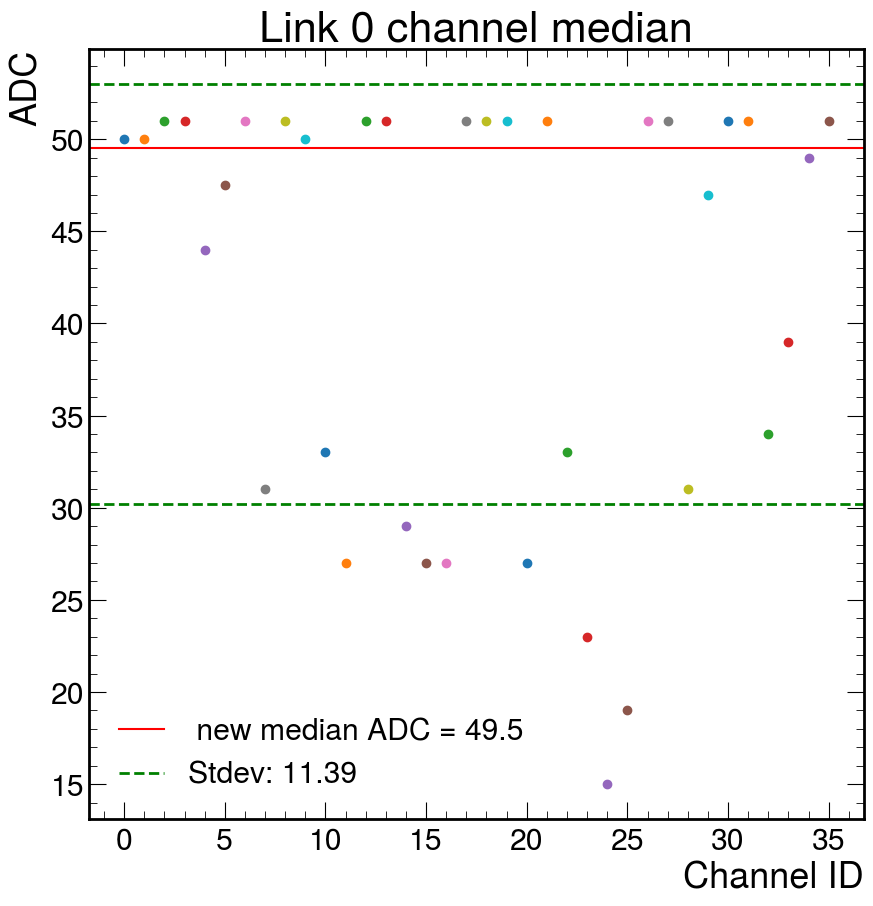

In [162]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    plt.scatter( x = i, y = median)
    l0_ch_med.append(median)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
plt.axhline(y = link_0_median, color = 'r', label = " new median ADC = "+str(link_0_median))
#plt.axhline(y = 209.5, color = 'b', label = " default median ADC = 209.5")
meanVal = np.mean(l0_ch_med)
stdVal = np.std(l0_ch_med)
#plt.axhline(meanVal, color='blue', linestyle='dashed', linewidth=2,label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)

plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")

In [ ]:
channels_settings = {}
#default_triminv= 0
#default_dacb = 0
#default_sign_dac = 0
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [31,0]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < link_0_median :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(link_0_median, adc_values, trim_inv))
        channels_settings[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_0_med[a], l0_ch_med[a]]
        new_dacb = round(np.interp(link_0_median, adc_values, dacb))
        channels_settings[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < link_1_median :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(link_1_median, adc_values, trim_inv))
        channels_settings[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(link_1_median, adc_values, dacb))
        channels_settings[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}

In [90]:
#link 1
adc_values = [31, 207] # new median and previous median
inv_vref = [540,416]
#link_0_median ## evaluate at this value
round(np.interp(50, adc_values, inv_vref))

527

In [91]:
#link 0
adc_values = [29.5, 209.5] # new median and previous median
inv_vref = [540,416]
#link_0_median ## evaluate at this value
round(np.interp(50, adc_values, inv_vref))

526

In [66]:
l1_ch_med[26]

206.0

In [51]:
high_inv_vref_link_1_med[26]

405.0

In [ ]:
with open ('med_100_channel_settings.yaml', 'w') as f:
    yaml.dump(channels_settings_med_100, f)